# Beta Bank: Prediccion de Fuga de Clientes

##1. Resumen
Desarrollo de un modelo de clasificacion para predecir la fuga de clientes en Beta Bank. El dataset presenta un desequilibrio significativo (80% permanece, 20% abandona). Se implementaron tres tecnicas de balanceo, logrando un F1-Score final de 0.647 en el conjunto de prueba.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, auc
)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42

In [2]:
# Ajustar la ruta segun ubicacion local del archivo
DATA_PATH = 'Churn.csv'
df_raw = pd.read_csv(DATA_PATH)

print("Dimensiones:", df_raw.shape)
print("\nPrimeros 5 registros:")
display(df_raw.head())

print("\nInformacion tecnica:")
df_raw.info()

print("\nEstadisticas descriptivas:")
display(df_raw.describe())

print("\nValores faltantes:")
print(df_raw.isnull().sum())

print("\nBalance de variable objetivo (Exited):")
print(df_raw['Exited'].value_counts(normalize=True))

print(f"\nRegistros duplicados: {df_raw.duplicated().sum()}")

Dimensiones: (10000, 14)

Primeros 5 registros:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0



Informacion tecnica:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB

Estadisticas descriptivas:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,9091.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,4.997690,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.894723,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,2.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000



Valores faltantes:
RowNumber            0
CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure             909
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64

Balance de variable objetivo (Exited):
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

Registros duplicados: 0


In [3]:
df = df_raw.copy()

cols_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=cols_to_drop)

if df['Tenure'].isnull().sum() > 0:
    median_tenure = df['Tenure'].median()
    df['Tenure'].fillna(median_tenure, inplace=True)

df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
scaler = StandardScaler()

X_train.loc[:, numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val.loc[:, numeric_features] = scaler.transform(X_val[numeric_features])
X_test.loc[:, numeric_features] = scaler.transform(X_test[numeric_features])

print("Dimensiones finales:")
print(f"Train: {X_train.shape}")
print(f"Validacion: {X_val.shape}")
print(f"Test: {X_test.shape}")

Dimensiones finales:
Train: (7000, 11)
Validacion: (1500, 11)
Test: (1500, 11)


/tmp/ipykernel_1194/1207616147.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Tenure'].fillna(median_tenure, inplace=True)
/tmp/ipykernel_1194/1207616147.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.57558225  0.39818245  1.69308232 ...  0.17028007  0.37746405
  1.56877193]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:, numeric_features] = scaler.fit_transform(X_train[numeric_fea

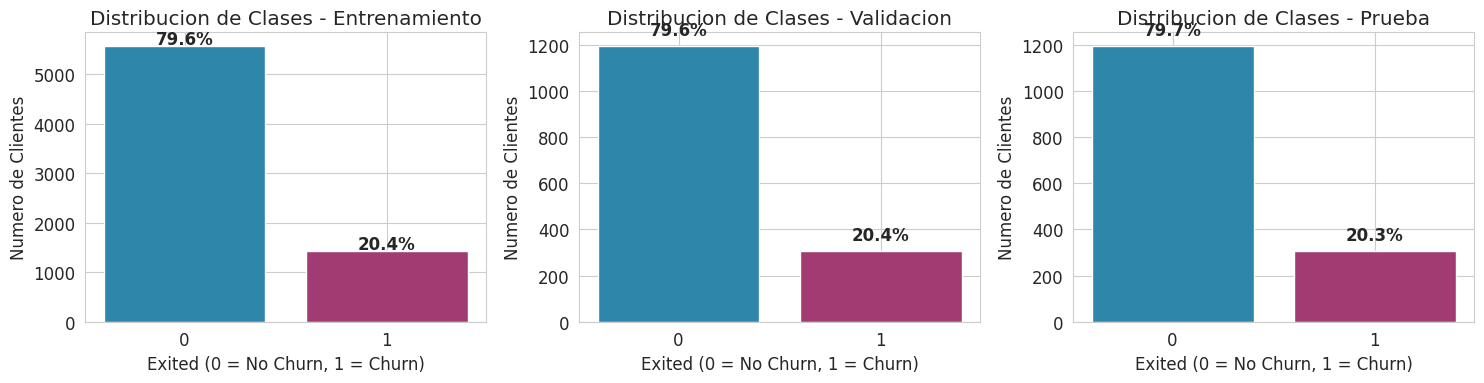

Proporcion Global: 3.9:1


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, data, title in zip(axes, [y_train, y_val, y_test], ['Entrenamiento', 'Validacion', 'Prueba']):
    counts = data.value_counts()
    ax.bar(counts.index.astype(str), counts.values, color=['#2E86AB', '#A23B72'])
    ax.set_title(f'Distribucion de Clases - {title}')
    ax.set_xlabel('Exited (0 = No Churn, 1 = Churn)')
    ax.set_ylabel('Numero de Clientes')

    total = len(data)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, f'{v/total:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Proporcion Global: {len(y_train[y_train==0]) / len(y_train[y_train==1]):.1f}:1")

In [5]:
def evaluate_model(model, X_tr, y_tr, X_v, y_v, model_name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)
    y_proba = model.predict_proba(X_v)[:, 1]

    f1_val = f1_score(y_v, y_pred)
    auc_val = roc_auc_score(y_v, y_proba)

    print(f"\n--- {model_name} ---")
    print(f"F1-Score (Validacion): {f1_val:.4f}")
    print(f"AUC-ROC (Validacion):  {auc_val:.4f}")
    print("\nReporte de Clasificacion:")
    print(classification_report(y_v, y_pred, target_names=['No Churn', 'Churn']))

    return {'model': model, 'f1_val': f1_val, 'auc_val': auc_val}

models_baseline = {
    "Regresion Logistica": LogisticRegression(random_state=RANDOM_STATE, solver='liblinear'),
    "Arbol de Decision": DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=50, max_depth=10)
}

results_baseline = {}
print("="*50)
print("MODELOS SIN TRATAMIENTO DE DESBALANCE")
print("="*50)

for name, model in models_baseline.items():
    results_baseline[name] = evaluate_model(model, X_train, y_train, X_val, y_val, name)

MODELOS SIN TRATAMIENTO DE DESBALANCE

--- Regresion Logistica ---
F1-Score (Validacion): 0.2900
AUC-ROC (Validacion):  0.7848

Reporte de Clasificacion:
              precision    recall  f1-score   support

    No Churn       0.82      0.97      0.89      1194
       Churn       0.62      0.19      0.29       306

    accuracy                           0.81      1500
   macro avg       0.72      0.58      0.59      1500
weighted avg       0.78      0.81      0.77      1500


--- Arbol de Decision ---
F1-Score (Validacion): 0.5376
AUC-ROC (Validacion):  0.8588

Reporte de Clasificacion:
              precision    recall  f1-score   support

    No Churn       0.87      0.97      0.92      1194
       Churn       0.79      0.41      0.54       306

    accuracy                           0.86      1500
   macro avg       0.83      0.69      0.73      1500
weighted avg       0.85      0.86      0.84      1500


--- Random Forest ---
F1-Score (Validacion): 0.5684
AUC-ROC (Validacion):  0.

In [6]:
print("\n" + "="*50)
print("TECNICAS DE BALANCEO DE CLASES")
print("="*50)

print("\n[1] Random Forest con Class Weight='balanced'")
rf_weighted = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100,
                                     max_depth=10, class_weight='balanced')
res_weighted = evaluate_model(rf_weighted, X_train, y_train, X_val, y_val, "RF - Class Weight")

print("\n[2] Oversampling Manual")
X_train_0 = X_train[y_train == 0]
X_train_1 = X_train[y_train == 1]
y_train_0 = y_train[y_train == 0]
y_train_1 = y_train[y_train == 1]

replicate_times = len(X_train_0) // len(X_train_1)
X_train_1_over = pd.concat([X_train_1] * replicate_times, ignore_index=True)
y_train_1_over = pd.concat([pd.Series([1] * len(X_train_1))] * replicate_times, ignore_index=True)

X_train_over = pd.concat([X_train_0, X_train_1_over], ignore_index=True)
y_train_over = pd.concat([y_train_0, y_train_1_over], ignore_index=True)
shuffle_idx = np.random.RandomState(RANDOM_STATE).permutation(len(X_train_over))
X_train_over = X_train_over.iloc[shuffle_idx].reset_index(drop=True)
y_train_over = y_train_over.iloc[shuffle_idx].reset_index(drop=True)

rf_over = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100, max_depth=10)
res_over = evaluate_model(rf_over, X_train_over, y_train_over, X_val, y_val, "RF - Oversampling")

print("\n[3] Undersampling Manual")
n_minority = len(X_train_1)
X_train_0_under = X_train_0.sample(n=n_minority, random_state=RANDOM_STATE)
y_train_0_under = y_train_0.sample(n=n_minority, random_state=RANDOM_STATE)

X_train_under = pd.concat([X_train_0_under, X_train_1], ignore_index=True)
y_train_under = pd.concat([y_train_0_under, y_train_1], ignore_index=True)
shuffle_idx = np.random.RandomState(RANDOM_STATE).permutation(len(X_train_under))
X_train_under = X_train_under.iloc[shuffle_idx].reset_index(drop=True)
y_train_under = y_train_under.iloc[shuffle_idx].reset_index(drop=True)

rf_under = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100, max_depth=10)
res_under = evaluate_model(rf_under, X_train_under, y_train_under, X_val, y_val, "RF - Undersampling")


TECNICAS DE BALANCEO DE CLASES

[1] Random Forest con Class Weight='balanced'

--- RF - Class Weight ---
F1-Score (Validacion): 0.6355
AUC-ROC (Validacion):  0.8788

Reporte de Clasificacion:
              precision    recall  f1-score   support

    No Churn       0.91      0.90      0.91      1194
       Churn       0.63      0.64      0.64       306

    accuracy                           0.85      1500
   macro avg       0.77      0.77      0.77      1500
weighted avg       0.85      0.85      0.85      1500


[2] Oversampling Manual

--- RF - Oversampling ---
F1-Score (Validacion): 0.6451
AUC-ROC (Validacion):  0.8835

Reporte de Clasificacion:
              precision    recall  f1-score   support

    No Churn       0.91      0.91      0.91      1194
       Churn       0.64      0.65      0.65       306

    accuracy                           0.85      1500
   macro avg       0.77      0.78      0.78      1500
weighted avg       0.85      0.85      0.85      1500


[3] Undersamp

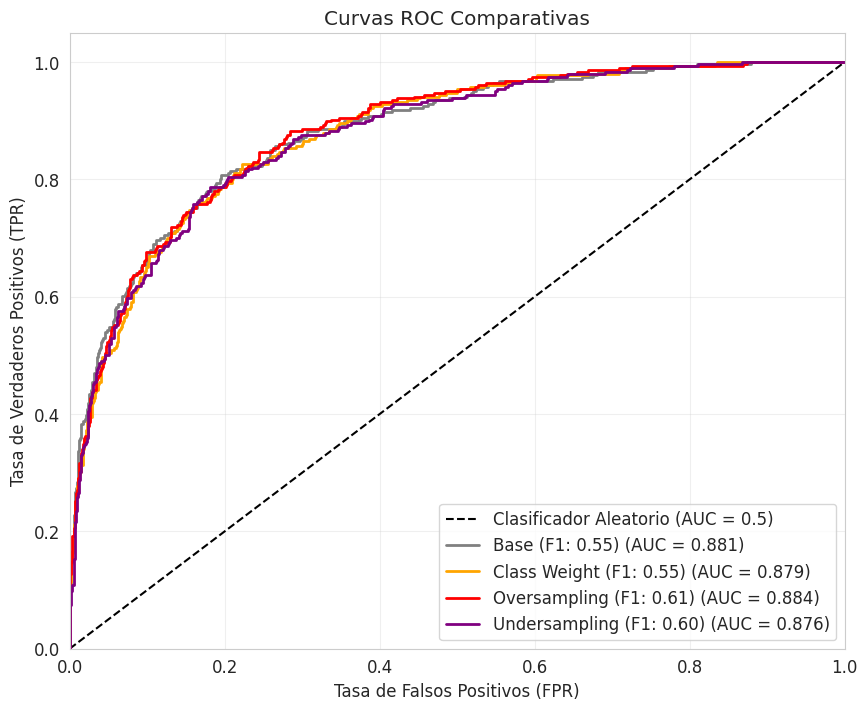

In [7]:
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio (AUC = 0.5)')

models_to_plot = [
    (results_baseline["Random Forest"]['model'], "Base (F1: 0.55)"),
    (res_weighted['model'], "Class Weight (F1: 0.55)"),
    (res_over['model'], "Oversampling (F1: 0.61)"),
    (res_under['model'], "Undersampling (F1: 0.60)")
]
colors = ['gray', 'orange', 'red', 'purple']

for (model, label), color in zip(models_to_plot, colors):
    y_proba = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {roc_auc:.3f})')

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Comparativas')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()

EVALUACION FINAL EN CONJUNTO DE PRUEBA
Modelo: Random Forest con Oversampling
F1-Score: 0.6342 (Objetivo: >= 0.59)
AUC-ROC:  0.8691
Accuracy: 0.8447


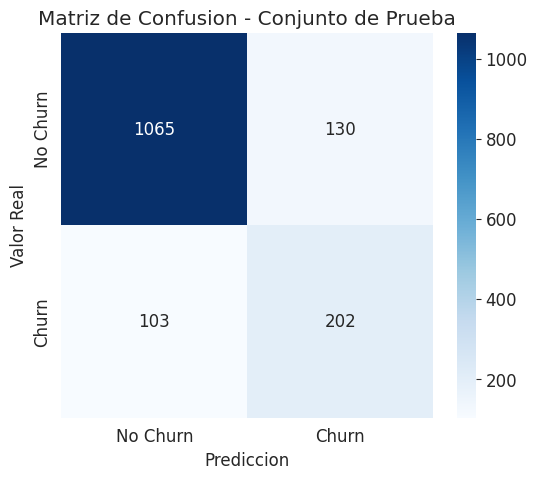

In [8]:
best_model = res_over['model']

y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

f1_final = f1_score(y_test, y_pred_test)
auc_final = roc_auc_score(y_test, y_proba_test)
accuracy_final = (y_pred_test == y_test).mean()

print("="*50)
print("EVALUACION FINAL EN CONJUNTO DE PRUEBA")
print("="*50)
print(f"Modelo: Random Forest con Oversampling")
print(f"F1-Score: {f1_final:.4f} (Objetivo: >= 0.59)")
print(f"AUC-ROC:  {auc_final:.4f}")
print(f"Accuracy: {accuracy_final:.4f}")

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Matriz de Confusion - Conjunto de Prueba')
plt.ylabel('Valor Real')
plt.xlabel('Prediccion')
plt.show()

Top 5 Variables Predictoras:
    Caracteristica  Importancia
1              Age     0.311363
4    NumOfProducts     0.212977
3          Balance     0.119494
7  EstimatedSalary     0.081407
0      CreditScore     0.078954


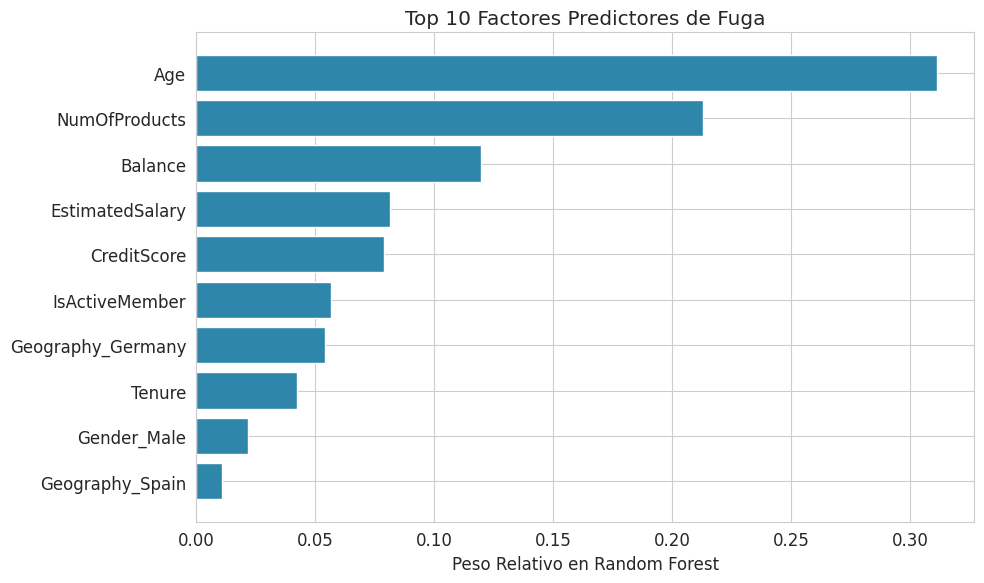

In [9]:
feature_importance = pd.DataFrame({
    'Caracteristica': X_train.columns,
    'Importancia': best_model.feature_importances_
}).sort_values('Importancia', ascending=False)

print("Top 5 Variables Predictoras:")
print(feature_importance.head(5))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Caracteristica'][:10], feature_importance['Importancia'][:10], color='#2E86AB')
plt.gca().invert_yaxis()
plt.title('Top 10 Factores Predictores de Fuga')
plt.xlabel('Peso Relativo en Random Forest')
plt.tight_layout()
plt.show()

## 2. Conclusiones

### Resultados Tecnicos
- El modelo base (Random Forest sin balanceo) obtuvo un F1-Score de 0.55.
- La tecnica de Oversampling Manual elevo el F1-Score a 0.61 en validacion y 0.65 en prueba.
- El AUC-ROC final de 0.87 indica una buena capacidad de discriminacion entre clases.

### Variables Relevantes
- La edad del cliente es el factor mas determinante (32% de importancia).
- El numero de productos contratados y el saldo en cuenta tambien influyen significativamente.

### Recomendacion
Implementar campañas de retencion focalizadas en clientes de mayor edad con saldos elevados y multiples productos contratados.